In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
import datasets as ds


In [3]:
METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
METEO_SWISS_MEAN_TEMP_GLOB = './datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc'
PW_FIRST_DATE    = '2017-01-03'
PW_LAST_DATE     = '2024-12-31'
NAN_THRESHOLD    = 0.99   # keep stations with ≥99% valid days (≤1% NaN)


In [4]:
daily_tmax_pw, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=NAN_THRESHOLD,
    station_type=None,
)
print(f"PW stations retained: {len(valid_stations)}")
print(daily_tmax_pw.head())


Loading PeakWeather stations (None) from 2017-01-03 to 2024-12-31 ...
  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2919, 172)  (2017-01-03 → 2024-12-30)
  Altitude range: [203, 3571] m
PW stations retained: 172
nat_abbr    ABO  AIG  ALT  AND   ANT  ARH   ARO   ATT  BAS   BEH  ...  VSSOR  \
datetime                                                          ...          
2017-01-03  2.1  4.0  1.5  1.6  -1.0  1.7  -0.1  -3.7  1.5  -3.0  ...    0.6   
2017-01-04 -3.0  3.8  2.2 -1.1  -5.3  0.6  -5.1  -5.7  0.3  -3.9  ...   -3.5   
2017-01-05  3.3  3.1  3.1 -0.4  -2.8  3.0  -3.0  -5.2  2.0  -2.7  ...   -0.2   
2017-01-06 -4.4  3.5  3.2 -2.7  -5.6  1.4  -9.1 -14.8  1.4 -11.3  ...   -9.2   
2017-01-07 -8.0 -1.4 -2.8 -7.1 -10.9 -4.1 -11.6  -8.6 -2.5 -11.3  ...   -9.3   

nat_abbr    VSTRI  VSTUR  VSVER  VSVIS  WAE   WFJ  WYN  ZER  ZWE  
datetime                                                          
2017-01-03    2.3   -0.1    3.5    2.9  1.4  -4.6  1.0  3.2  3.8  


In [5]:
from peakweather import PeakWeatherDataset
pw_ds_mean = PeakWeatherDataset(
    station_type=None,
    imputation_method=None,
    freq='D',
    aggregation_methods={'temperature': 'mean'},
)
df_mean = pw_ds_mean.get_observations(
    parameters=['temperature'],
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
)
daily_tmean_pw = df_mean.xs('temperature', axis=1, level=1)
daily_tmean_pw.index = daily_tmean_pw.index.tz_localize(None)

daily_tmean_pw = daily_tmean_pw[valid_stations]


In [6]:
ms_ds = xr.open_mfdataset(METEO_SWISS_MAX_TEMP_GLOB, combine='by_coords', data_vars='all')
ms_mean_ds = xr.open_mfdataset(METEO_SWISS_MEAN_TEMP_GLOB, combine='by_coords', data_vars='all')
print(ms_ds)
ms_N = ms_ds['N'].values   
ms_E = ms_ds['E'].values   
print(f"MeteoSwiss N range: [{ms_N.min():.0f}, {ms_N.max():.0f}]")
print(f"MeteoSwiss E range: [{ms_E.min():.0f}, {ms_E.max():.0f}]")


<xarray.Dataset> Size: 7GB
Dimensions:                 (time: 19358, N: 240, E: 370)
Coordinates:
  * time                    (time) datetime64[ns] 155kB 1971-01-01 ... 2023-1...
  * N                       (N) float64 2kB 1.064e+06 1.066e+06 ... 1.304e+06
  * E                       (E) float64 3kB 2.474e+06 2.476e+06 ... 2.844e+06
    lon                     (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
    lat                     (N, E) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
Data variables:
    swiss_lv95_coordinates  (time) float32 77kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    TmaxD                   (time, N, E) float32 7GB dask.array<chunksize=(365, 240, 370), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    institution:  Data produced at Federal Office of Meteorology and Climatol...
    title:        Spatial Climate Analyses Dataset of MeteoSwiss (TmaxD)
    history:      2023-11-23 16:42:41 - generated by gridmch 7.28.1
    

In [7]:
station_cell = {}   # station_code -> (N_idx, E_idx)
for stn in valid_stations:
    north = stations_meta.loc[stn, 'swiss_northing']
    east  = stations_meta.loc[stn, 'swiss_easting']
    n_idx = int(np.argmin(np.abs(ms_N - north)))
    e_idx = int(np.argmin(np.abs(ms_E - east)))
    station_cell[stn] = (n_idx, e_idx)

# Sanity check — show distance from station to matched cell centre
print("Station → nearest MeteoSwiss cell (first 5):")
for stn in valid_stations[:5]:
    n_idx, e_idx = station_cell[stn]
    dn = abs(stations_meta.loc[stn, 'swiss_northing'] - ms_N[n_idx])
    de = abs(stations_meta.loc[stn, 'swiss_easting']  - ms_E[e_idx])
    print(f"  {stn:8s}  ΔN={dn:.0f} m  ΔE={de:.0f} m  "
          f"(cell [{n_idx},{e_idx}])")


Station → nearest MeteoSwiss cell (first 5):
  ABO       ΔN=439 m  ΔE=128 m  (cell [84,135])
  AIG       ΔN=214 m  ΔE=97 m  (cell [66,86])
  ALT       ΔN=63 m  ΔE=319 m  (cell [129,216])
  AND       ΔN=463 m  ΔE=192 m  (cell [100,278])
  ANT       ΔN=457 m  ΔE=55 m  (cell [101,213])


In [8]:
# Load MeteoSwiss 2D lat/lon grid
ms_lat_grid = ms_ds['lat'].values 
ms_lon_grid = ms_ds['lon'].values 

# Load hi-res DEM for cell altitude
HI_RES_TOPO_PATH = './datasets/topo_subset.zarr'
topo_ds = xr.open_zarr(HI_RES_TOPO_PATH)
print(topo_ds)
elev_var = 'DEM' 

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))

station_dist_km  = {}
station_alt_diff = {}   # station altitude − cell DEM altitude (m)

for stn in valid_stations:
    n_idx, e_idx = station_cell[stn]

    # Cell centre lat/lon from MeteoSwiss 2D coordinate arrays
    cell_lat = float(ms_lat_grid[n_idx, e_idx])
    cell_lon = float(ms_lon_grid[n_idx, e_idx])
    stn_lat  = stations_meta.loc[stn, 'latitude']
    stn_lon  = stations_meta.loc[stn, 'longitude']

    station_dist_km[stn] = haversine_km(stn_lat, stn_lon, cell_lat, cell_lon)

    # Cell altitude from hi-res DEM interpolated at LV95 cell centre
    cell_alt = float(
        topo_ds[elev_var].interp(
            x=float(ms_E[e_idx]),
            y=float(ms_N[n_idx]),
            method='nearest',
        ).values
    )
    station_alt_diff[stn] = stations_meta.loc[stn, 'station_height'] - cell_alt

print("Sample distances and altitude diffs:")
for stn in valid_stations[:5]:
    print(f"  {stn}: dist={station_dist_km[stn]:.2f} km  "
          f"alt_diff={station_alt_diff[stn]:+.0f} m")


<xarray.Dataset> Size: 11GB
Dimensions:                        (y: 12800, x: 14200)
Coordinates:
  * y                              (y) float64 102kB 8.4e+05 ... 1.48e+06
  * x                              (x) float64 114kB 2.255e+06 ... 2.965e+06
    latitude                       (y, x) float64 1GB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    longitude                      (y, x) float64 1GB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
Data variables:
    DEM                            (y, x) int16 364MB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    EASTING                        (y, x) float64 1GB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    NORTHING                       (y, x) float64 1GB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    SN_DERIVATIVE_2000M_SIGRATIO1  (y, x) float32 727MB dask.array<chunksize=(3200, 3550), meta=np.ndarray>
    SN_DERIVATIVE_500M_SIGRATIO1   (y, x) float32 727MB dask.array<chunksize=(3200, 3550), meta=np

In [9]:
pw_dates_shifted = daily_tmax_pw.index - pd.Timedelta(days=1)
daily_tmax_pw_aligned  = daily_tmax_pw.copy()
daily_tmax_pw_aligned.index  = pw_dates_shifted
daily_tmean_pw_aligned = daily_tmean_pw.copy()
daily_tmean_pw_aligned.index = daily_tmean_pw.index - pd.Timedelta(days=1)

ms_tmax_times  = pd.DatetimeIndex(ms_ds['time'].values)
ms_tmean_times = pd.DatetimeIndex(ms_mean_ds['time'].values)
common_dates   = ms_tmax_times.intersection(ms_tmean_times).intersection(pw_dates_shifted)
print(f"Common dates after alignment: {len(common_dates)}  "
      f"({common_dates[0].date()} → {common_dates[-1].date()})")

def extract_ms_at_stations(ms_dataset, var_name, dates, stations, cell_map):
    """Extract MeteoSwiss pixel time-series at each station cell."""
    out = np.full((len(dates), len(stations)), np.nan, dtype=np.float32)
    for j, stn in enumerate(stations):
        n_idx, e_idx = cell_map[stn]
        out[:, j] = (
            ms_dataset[var_name]
            .sel(time=dates)
            .isel(N=n_idx, E=e_idx)
            .values
            .astype(np.float32)
        )
    return out

ms_tmax_at_stns  = extract_ms_at_stations(ms_ds,      'TmaxD', common_dates, valid_stations, station_cell)
ms_tmean_at_stns = extract_ms_at_stations(ms_mean_ds, 'TabsD', common_dates, valid_stations, station_cell)

pw_tmax_at_stns  = daily_tmax_pw_aligned.loc[common_dates,  valid_stations].values.astype(np.float32)
pw_tmean_at_stns = daily_tmean_pw_aligned.loc[common_dates, valid_stations].values.astype(np.float32)

print(f"Tmax  arrays: PW {pw_tmax_at_stns.shape}  MS {ms_tmax_at_stns.shape}")
print(f"Tmean arrays: PW {pw_tmean_at_stns.shape}  MS {ms_tmean_at_stns.shape}")

Common dates after alignment: 2555  (2017-01-02 → 2023-12-31)
Tmax  arrays: PW (2555, 172)  MS (2555, 172)
Tmean arrays: PW (2555, 172)  MS (2555, 172)


In [10]:
def compute_station_errors(pw_vals_2d, ms_vals_2d, stations, stations_meta, min_days=30):
    records = []
    for j, stn in enumerate(stations):
        pw = pw_vals_2d[:, j]
        ms = ms_vals_2d[:, j]
        valid = ~np.isnan(pw) & ~np.isnan(ms)
        n_valid = int(valid.sum())
        if n_valid < min_days:
            continue
        diff = pw[valid] - ms[valid]
        records.append(dict(
            station      = stn,
            station_name = stations_meta.loc[stn, 'station_name'],
            latitude     = stations_meta.loc[stn, 'latitude'],
            longitude    = stations_meta.loc[stn, 'longitude'],
            altitude_m   = stations_meta.loc[stn, 'station_height'],
            dist_km      = round(station_dist_km[stn], 2),
            alt_diff_m   = round(station_alt_diff[stn], 0),
            n_valid_days = n_valid,
            MAE          = float(np.mean(np.abs(diff))),
            RMSE         = float(np.sqrt(np.mean(diff**2))),
            Bias         = float(np.mean(diff)),
            Corr         = float(np.corrcoef(pw[valid], ms[valid])[0, 1]),
        ))
    return pd.DataFrame(records).sort_values('MAE').reset_index(drop=True)


results_tmax  = compute_station_errors(pw_tmax_at_stns,  ms_tmax_at_stns,  valid_stations, stations_meta)
results_tmean = compute_station_errors(pw_tmean_at_stns, ms_tmean_at_stns, valid_stations, stations_meta)

print(f"Tmax  — stations with ≥30 matchable days: {len(results_tmax)}")
print(f"Tmean — stations with ≥30 matchable days: {len(results_tmean)}")


Tmax  — stations with ≥30 matchable days: 172
Tmean — stations with ≥30 matchable days: 172


In [11]:
display_cols = ['station', 'station_name', 'altitude_m', 'dist_km', 'alt_diff_m',
                'n_valid_days', 'MAE', 'RMSE', 'Bias', 'Corr']

for label, df in [('Daily Max (Tmax)', results_tmax), ('Daily Mean (Tmean)', results_tmean)]:
    print(f"\n{'='*70}")
    print(f"  {label} — PeakWeather vs MeteoSwiss")
    print(f"{'='*70}")
    with pd.option_context('display.max_rows', None, 'display.float_format', '{:.2f}'.format):
        print(df[display_cols].to_string(index=False))
    print(f"\n  Median MAE:  {df['MAE'].median():.2f} °C")
    print(f"  Median RMSE: {df['RMSE'].median():.2f} °C")
    print(f"  Median Bias: {df['Bias'].median():.2f} °C")
    print(f"  Median Corr: {df['Corr'].median():.3f}")




  Daily Max (Tmax) — PeakWeather vs MeteoSwiss
station              station_name  altitude_m  dist_km  alt_diff_m  n_valid_days  MAE  RMSE  Bias  Corr
    MAG      Magadino / Cadenazzo      203.20     0.34        0.00          2555 0.00  0.01  0.00  1.00
    PAY                   Payerne      490.00     0.38        2.00          2555 0.00  0.02 -0.00  1.00
    RAG                 Bad Ragaz      496.50     0.44        2.00          2553 0.00  0.04 -0.00  1.00
    KLO           Zürich / Kloten      426.26     0.27       -1.00          2555 0.01  0.05 -0.00  1.00
    REH        Zürich / Affoltern      443.53     0.08        4.00          2555 0.01  0.06  0.00  1.00
    BER         Bern / Zollikofen      552.84     0.44       13.00          2555 0.01  0.03 -0.00  1.00
    BUS             Buchs / Aarau      386.66     0.17        4.00          2555 0.01  0.11 -0.01  1.00
    LAG              Langnau i.E.      743.80     0.57       -1.00          2553 0.01  0.25 -0.01  1.00
    LUG         

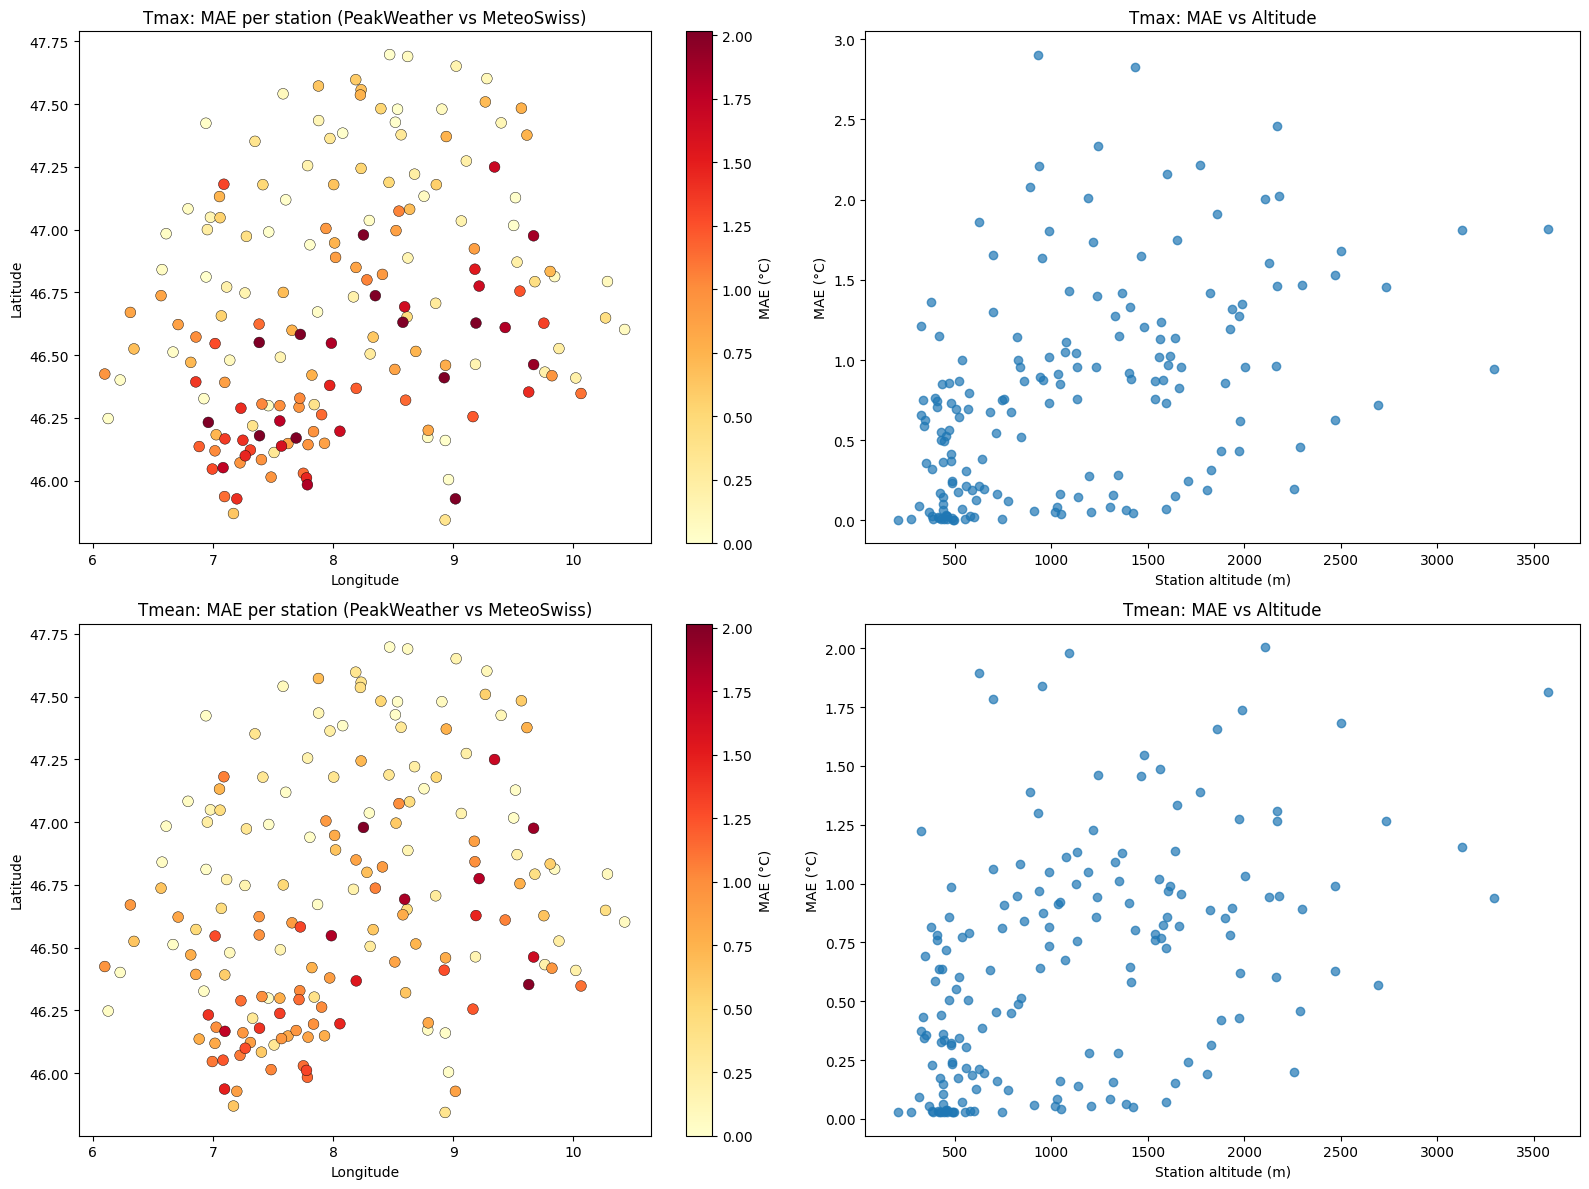

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
vmax = max(results_tmax['MAE'].quantile(0.95), results_tmean['MAE'].quantile(0.95))

for row, (label, df) in enumerate([('Tmax', results_tmax), ('Tmean', results_tmean)]):
    # Map coloured by MAE
    sc = axes[row, 0].scatter(
        df['longitude'], df['latitude'],
        c=df['MAE'], cmap='YlOrRd', s=60,
        vmin=0, vmax=vmax, edgecolors='k', linewidths=0.3,
    )
    plt.colorbar(sc, ax=axes[row, 0], label='MAE (°C)')
    axes[row, 0].set_title(f'{label}: MAE per station (PeakWeather vs MeteoSwiss)')
    axes[row, 0].set_xlabel('Longitude'); axes[row, 0].set_ylabel('Latitude')

    # MAE vs altitude
    axes[row, 1].scatter(df['altitude_m'], df['MAE'], alpha=0.7)
    axes[row, 1].set_xlabel('Station altitude (m)')
    axes[row, 1].set_ylabel('MAE (°C)')
    axes[row, 1].set_title(f'{label}: MAE vs Altitude')

plt.tight_layout()
plt.show()


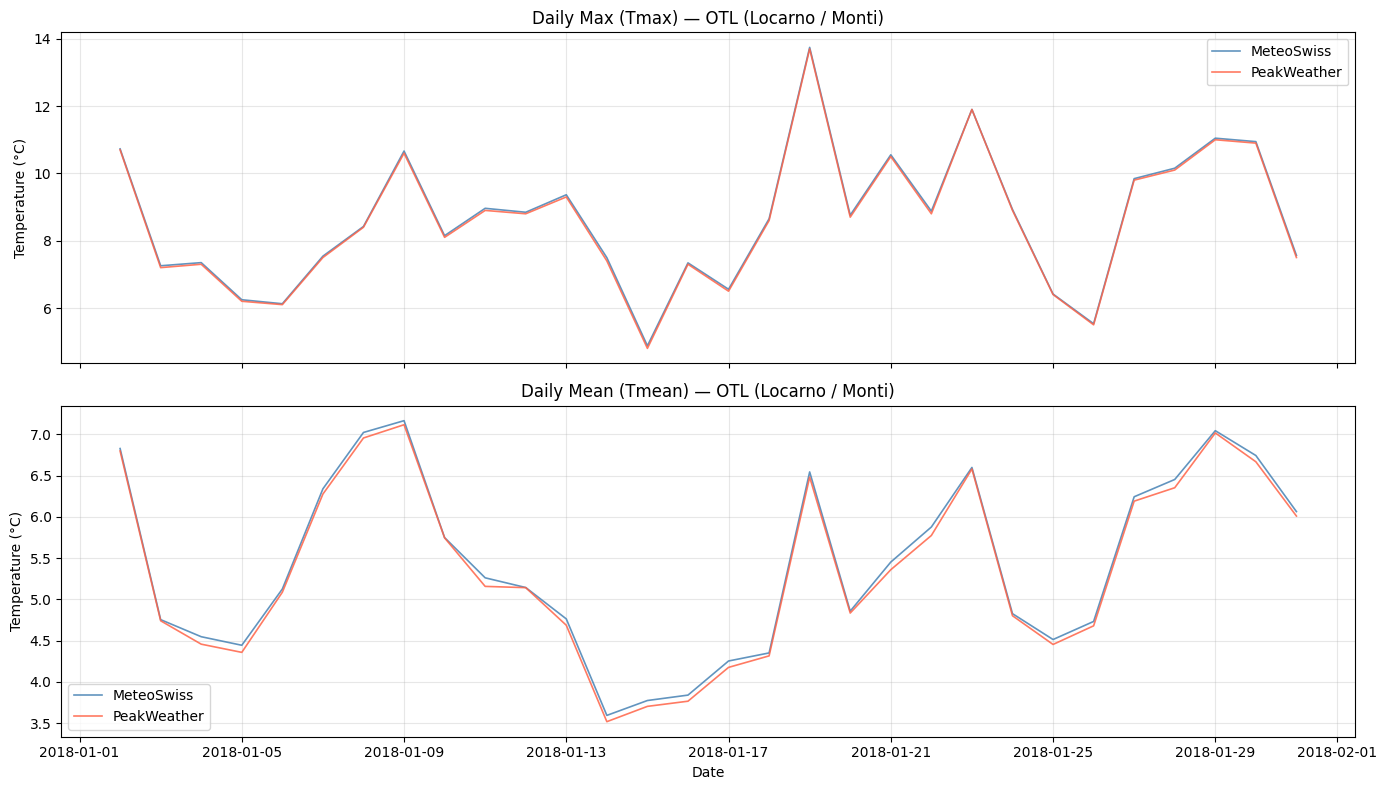

In [17]:
SELECTED_STATION = 'OTL'         # PeakWeather station code
PLOT_START_DATE  = '2018-01-02'
PLOT_END_DATE    = '2018-01-31'

date_mask = (common_dates >= PLOT_START_DATE) & (common_dates <= PLOT_END_DATE)
plot_dates = common_dates[date_mask]

if SELECTED_STATION not in valid_stations:
    raise ValueError(f"Station '{SELECTED_STATION}' not in valid_stations. "
                     f"Check the station code or NaN threshold.")

j = valid_stations.index(SELECTED_STATION)
stn_name = stations_meta.loc[SELECTED_STATION, 'station_name']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, label, pw_2d, ms_2d in [
    (axes[0], 'Daily Max (Tmax)',  pw_tmax_at_stns,  ms_tmax_at_stns),
    (axes[1], 'Daily Mean (Tmean)', pw_tmean_at_stns, ms_tmean_at_stns),
]:
    pw_series = pw_2d[date_mask, j]
    ms_series = ms_2d[date_mask, j]

    ax.plot(plot_dates, ms_series, color='steelblue', linewidth=1.2,
            label='MeteoSwiss', alpha=0.85)
    ax.plot(plot_dates, pw_series, color='tomato',    linewidth=1.2,
            label='PeakWeather', alpha=0.85)

    ax.set_ylabel('Temperature (°C)')
    ax.set_title(f'{label} — {SELECTED_STATION} ({stn_name})')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()


In [14]:
DIFF_THRESHOLD = 5.0   # °C

diff_tmean = pw_tmean_at_stns - ms_tmean_at_stns   # (n_dates, n_stations)

day_idxs, stn_idxs = np.where(np.abs(diff_tmean) >= DIFF_THRESHOLD)

records = []
for d, s in zip(day_idxs, stn_idxs):
    diff_val = diff_tmean[d, s]
    if np.isnan(diff_val):
        continue
    stn = valid_stations[s]
    records.append(dict(
        station      = stn,
        station_name = stations_meta.loc[stn, 'station_name'],
        date         = common_dates[d].date(),
        diff_degC    = round(float(diff_val), 2),   # positive = PW warmer than MeteoSwiss
    ))

large_diff_df = (
    pd.DataFrame(records)
    .sort_values('diff_degC', key=np.abs, ascending=False)
    .reset_index(drop=True)
)

print(f"Events with |ΔT| ≥ {DIFF_THRESHOLD}°C (daily mean, PW − MeteoSwiss): "
      f"{len(large_diff_df)}")
with pd.option_context('display.max_rows', None, 'display.float_format', '{:.2f}'.format):
    print(large_diff_df[['station', 'station_name', 'diff_degC', 'date']].to_string(index=False))


Events with |ΔT| ≥ 5.0°C (daily mean, PW − MeteoSwiss): 1321
station              station_name  diff_degC       date
    SRS                   Schiers     -16.69 2019-12-17
    VIO               Vicosoprano      16.17 2021-12-16
  VSSOR   Sorniot / Lac Inférieur     -16.11 2021-12-20
  VSSOR   Sorniot / Lac Inférieur     -15.98 2022-01-13
  VSSOR   Sorniot / Lac Inférieur     -15.92 2021-12-19
    SRS                   Schiers     -15.80 2017-01-27
  VSSOR   Sorniot / Lac Inférieur     -15.62 2017-12-24
    VIO               Vicosoprano      15.47 2017-01-09
  VSSOR   Sorniot / Lac Inférieur     -15.41 2021-12-22
    VIO               Vicosoprano      15.34 2021-12-17
  VSSOR   Sorniot / Lac Inférieur     -15.33 2022-01-14
    VIO               Vicosoprano      15.31 2017-12-24
    SRS                   Schiers     -14.99 2021-02-22
    VIO               Vicosoprano      14.73 2019-12-29
  VSSOR   Sorniot / Lac Inférieur     -14.64 2022-01-12
  VSSOR   Sorniot / Lac Inférieur     -14.6

In [15]:
count_df = (
    large_diff_df.groupby(['station', 'station_name'], sort=False)
    .size()
    .reset_index(name='n_events')
    .sort_values('n_events', ascending=False)
    .reset_index(drop=True)
)

print(f"\nStations with at least one |ΔT| ≥ {DIFF_THRESHOLD}°C event:")
with pd.option_context('display.max_rows', None):
    print(count_df[['station', 'station_name', 'n_events']].to_string(index=False))



Stations with at least one |ΔT| ≥ 5.0°C event:
station              station_name  n_events
    ILZ                     Ilanz       208
    SRS                   Schiers       203
  VSSOR   Sorniot / Lac Inférieur       182
    VIO               Vicosoprano       180
    GOS                 Göschenen        70
    KIE                   Kiental        54
  VSVIS            Visperterminen        41
    SIM              Simplon-Dorf        41
  VSFLY                  La Fouly        34
    GEN            Monte Generoso        24
    VLS                      Vals        19
    ZWE                Zweisimmen        19
    BIV                     Bivio        19
  VSJEI                  Jeizinen        18
    GAD                    Gadmen        18
    GOR                Gornergrat        18
    MOB        Montagnier, Bagnes        16
  VSFIN                  Findelen        14
  VSCHO                     Choëx        13
    MAR            Les Marécottes        13
    BOL                  Bol